# INF8775 – Analyse et conception d’algorithmes
# TP1 – Automne 2025

CRUZ PULGARIN, Delany , 2218061

NOM, Prénom, 1234567

Note finale :

 **Date limite de remise :** 30 septembre (B2)

# Instructions

## Rédaction et remise du rapport

- Ce notebook constitue à la fois le sujet du TP, votre code et votre rapport. Il contient déjà du code pour faciliter vos mesures et l'affichage de vos résultats, ainsi qu'un squelette pour votre rapport.

- Complétez directement le notebook, vous êtes libres de créer de nouvelles cellules de code ou de texte.

- Les questions et tâches à effectuées sont généralement indiquées par un TODO, mais lisez attentivement car nous pourrions avoir oublié d'en indiquer certaines.

- Des questions sont réutilisées d'un algorithme à l'autre (puisque l'on reproduit les expérimentations à des fins de comparaisons). Veillez à suffisament développer les premières réponses afin de l'on comprenne bien votre raisonnement et pour montrer votre bonne compréhension. Vous pourrez être plus concis par la suite.

- Remettez le fichier du notebook sur Moodle avec le nom `NOM1_MATRICULE1_NOM2_MATRICULE2.ipynb`

- Vous pouvez inclure du code trouvé sur Internet, mais vous devez en mentionner la source, sous peine d'être sanctionnés pour plagiat. Cela s'applique aussi au niveau de l'IA générative pour le code. Par contre, vous devez être capable d'accomplir les analyses par vous-même. Vous ne pouvez pas utiliser l'IA pour ces sections.

## Mise en situation

Ce travail pratique se répartit sur deux séances de laboratoire et porte sur l’analyse empirique et hybride des algorithmes. Dans les capsules vidéo de la semaine 3, trois approches d’analyse de l’implantation d’un algorithme sont décrites. Vous les mettrez en pratique pour des algorithmes de résolution d’un problème connu.


## Description du problème

On vous demande de résoudre le problème de la ligne d’horizon (The Skyline Problem) qui consiste à dessiner la silhouette de bâtiments lorsqu’ils sont vus de loin. Ces bâtiments sont juxtaposés l’un à l’autre et il est possible que l’un en cache un autre.

Chaque bâtiment est défini par le triplet `(l, r, h)` avec `h` la hauteur du bâtiment et `l` et `r` les abscisses des murs gauche et droit, respectivement.

La solution représente une suite de couples `(x, h)` représentant les coordonnées des points définissant la silhouette des bâtiments.

Soit l’exemple suivant avec 5 bâtiments :

- L'exemplaire est : `(2, 9, 10), (3, 7, 15), (5, 12, 12), (15, 20, 10),
(19, 24, 8)`
- La solution est : `(2, 10), (3, 15), (7, 12), (12, 0), (15, 10), (20, 8), (24, 0)`

La figure B représente la silhouette (et donc la solution) tracée par les bâtiments colorés de la figure A.

In [298]:
# Problem data
example_buildings = [(2, 9, 10), (3, 7, 15), (5, 12, 12), (15, 20, 10), (19, 24, 8)]

# Solution data
example_skyline = [(2, 10), (3, 15), (7, 12), (12, 0), (15, 10), (20, 8), (24, 0)]

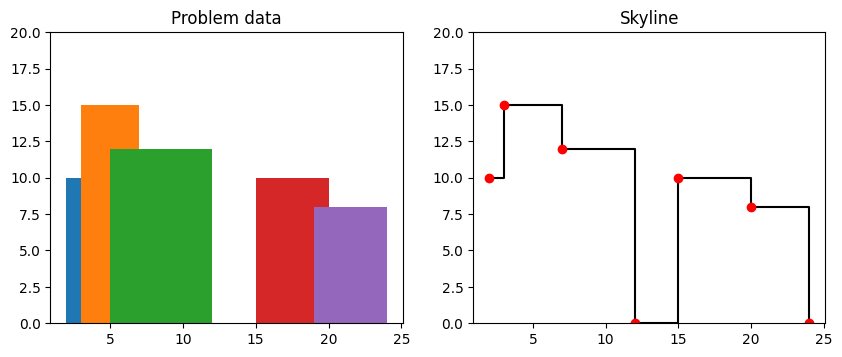

In [299]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and a set of subplots with equal width
fig, axs = plt.subplots(1, 2, figsize=(10,5), gridspec_kw={'width_ratios': [1, 1]})

# Create the first subplot to show the problem data as colored filled rectangles
for building in example_buildings:
 left, right, height = building
 axs[0].fill([left, right, right, left], [0, 0, height, height])

axs[0].set_ylim([0, 20])
axs[0].set_aspect('equal')
axs[0].set_title('Problem data')

# Create the second subplot to plot the skyline as a staircase function
x = [x for x, _ in example_skyline]
y = [y for _, y in example_skyline]
axs[1].step(x, y, where='post', color='black')

# Add the solution points as red dots
axs[1].plot(x, y, 'ro')

axs[1].set_ylim([0, 20])
axs[1].set_aspect('equal')
axs[1].set_title('Skyline')

plt.show()


## Algorithmes à implanter

On vous demande de résoudre ce problème de 3 façons différentes :

1. En utilisant un algorithme force brute simple ;
2. En utilisant un algorithme diviser pour régner ;
3. En utilisant un algorithme diviser pour régner avec seuil de récursivité non élémentaire.

Pour l’algorithme 3, vous devrez déterminer un seuil de récursivité expérimentalement. Les exemplaires dont la taille est en deçà de ce seuil ne sont plus résolus récursivement mais plutôt directement avec l’algorithme 1.

Vos algorithmes doivent donner des réponses où les couples `(x, h)` sont triés de façon non décroissante selon x (cf. exemple plus haut). Par ailleurs, ils ne doivent pas donner de solutions avec couples redondants, i.e. deux couples qui se suivent ne peuvent pas avoir la même hauteur ni la même abscisse.


## Jeu de données

La fonction `generate_sample` ci-dessous permet de générer un exemplaire d'une taille donnée.

La fonction `get_dataset` permet de récupérer un dataset pour la liste de taille fournie. Elle prend également en entrée un graine aléatoire pour générer le dataset en question.

Afin que chaque groupe travaille avec un set différent, mais que vos propres expériences soient reproductibles, entrez l'un de vous matricule comme graine aléatoire dans la cellule ci-dessous.

Vous êtes bien entendu libres de tester et mesurer vos algorithme sur le même dataset qu'un autre groupe. Pour cela, générez simplement un dataset avec la même graine et la même liste de taille.



In [300]:
import random

max_width = 50
max_dist = 30
max_height = 300

def generate_sample(size):
    sample = []
    last_l = 0
    for _ in range(size):
        l = random.randint(last_l, last_l + max_dist)
        r = random.randint(l+1, l + max_width)
        h = random.randint(1, max_height)
        sample.append((l, r, h))
        last_l = l
    return sample

def get_dataset(seed, sizes):
    random.seed(seed)
    return { size: [generate_sample(size) for _ in range(5)]
        for size in sizes }

In [301]:
# TODO: Utilisez un de vos matricules comme graine et une liste de tailles judicieusement choisies
# On teste le cas limite 0 (liste vide), lorsqu'il y a juste 1 bâtiment (aucun tri à faire), 
# au moin une liste aux nombre pair et impair" et une grande liste (100)
# dataset = get_dataset(2218061, [0,1,10,100, 500, 1000, 5000, 10000, 20000, 50000])
# dataset = get_dataset(2218061, [50, 100, 200, 500, 1000, 2000, 5000, 10000])
dataset = get_dataset(2218061, [1,16,32,64,512,768,1024,4096,8192])


# Implantations et expérimentations

Ces fonctions auxiliaires vous sont fournies pour vérifier l'exactitude des vos algorithmes, mesurer leurs performance et afficher vos résultats.

Il est recommandé de prendre le temps de lire et comprendre le code.

Exécutez la cellule ci-dessous pour pouvoir utiliser les fonctions auxiliaires.

In [302]:
import matplotlib.pyplot as plt
import time
import statistics as stats

def verification_plot(buildings, skyline):
    # Create a figure and a set of subplots with equal width
    fig, ax = plt.subplots(figsize=(10,5))

    # Create the first subplot to show the problem data as colored filled rectangles
    for building in buildings:
        left, right, height = building
        ax.fill([left, right, right, left], [0, 0, height, height])

    # Create the second subplot to plot the skyline as a staircase function
    x = [x for x, _ in skyline]
    y = [y for _, y in skyline]
    ax.step(x, y, where='post', color='black')

    # Add the solution points as red dots
    ax.plot(x, y, 'ro')

    plt.show()


def measure(procedure, sample):
    """ Mesure le temps d'execution d'une procédure sur un unique exemplaire """
    start = time.time()
    solution = procedure(sample)
    end = time.time()
    sorting_time = end - start
    return solution, sorting_time


def measure_mean_time(procedure, samples):
    """ Mesure le temps moyen d'execution d'une procédure sur une liste d'exemplaires """
    total_time = 0
    for sample in samples:
        solution, compute_time = measure(procedure, sample)
        total_time += compute_time
    return total_time / len(samples)


def measure_procedure(procedure, dataset):
    """ Mesure les temps moyens d'execution d'une procédure sur chaque point d'un dataset """
    return {size: measure_mean_time(procedure, samples) for size, samples in dataset.items()}

def display_measures_table(measures):
    print("{: <12} {: <12}".format("Taille", "Temps moyen (s)"))
    for size, measure in measures.items():
        print("{: <12} {: <12}".format(size, measure))


def display_test_puissance(vals, title="Test de puissance"):
    x = list(vals.keys())
    y = list(vals.values())

    # Perform linear regression
    m, b = stats.linear_regression(x, y)

    r = list(map(lambda x : m*x + b, x))

    # Create the line equation
    line_eq = f"y = {m:.2f}x + {b:.2f}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, r, color="red", label='Regression linéaire')

    # Add labels and title
    plt.xlabel('log Taille')
    plt.ylabel('log Temps')
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

def display_test_rapport(vals, title="Test du rapport"):
    x = list(vals.keys())
    y = list(vals.values())

    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Taille')
    plt.ylabel('Temps / f(taille)')
    plt.title(title)
    plt.show()


def display_test_constantes(vals, title="Test des constantes"):
    x = list(vals.keys())
    y = list(vals.values())

    # Perform linear regression
    m, b = stats.linear_regression(x, y)

    r = list(map(lambda x : m*x + b, x))

    # Create the line equation
    line_eq = f"y = {m:.2E}x + {b:.2E}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, r, color="red", label='Regression linéaire')

    # Add labels and title
    plt.xlabel('f(Taille)')
    plt.ylabel('Temps')
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()


def display_mesures_seuil(vals):
    x = list(vals.keys())
    y = list(vals.values())
    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Seuil')
    plt.ylabel('Temps')
    plt.title('Selection du seuil')
    plt.show()




## Algorithme naïf (brute force) (6 points)

### Implémentation (1.5 points)

TODO: Implantez un algorithme naïf pour le problème de la ligne d'horizon.

TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

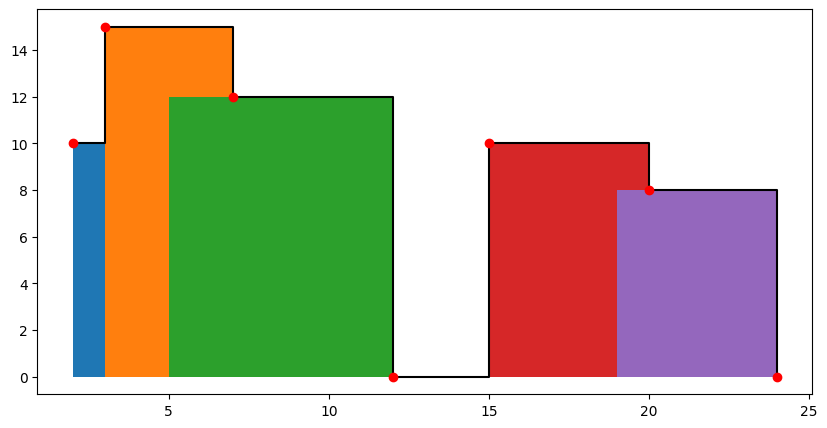

In [303]:
def skyline_bruteforce(buildings):
    # TODO : Implantez un algorithme naïf
    # Cet algorithme est inspiré sur le code fournie par GeeksForGeeks - The Skyline Problem | Set-1
    # Lien : https://www.geeksforgeeks.org/dsa/the-skyline-problem-using-divide-and-conquer-algorithm/
    
    # Innitialisation des variables
    skyline = []
    pointsCritiques = []
    prevH = 0

    # On gère le cas limite où il n'y a aucun bâtiment
    if len(buildings) == 0: 
        return skyline

    # On récupère tout les points sur l'axe des x (ils représentent le côté droit(r) et gauche(l) de chaque bâtiment)
    for b in buildings:
        pointsCritiques.append(b[0])
        pointsCritiques.append(b[1])
    pointsCritiques.sort() #trier les pts critiques selon l'axe des x

    
    for x in pointsCritiques:
        maxH = 0
        for l, r, h in buildings:
            #On vérifie su x est dans l'aire du batiment
            # Si oui, on ajoute seulement la hauteure max (on ne prend pas en compte les bâtiments cachés par d'autre bâtiments dans le skiline)
            if l <= x <r:
                maxH = max(maxH,h)
        # Condition qui vérifie si la liste des point du skiline est vide (est vrai pour le tout premier point)
        # et si il y a un changement de hauteur. Si une des deux condition est satisfaite, on ajoute le point x,maxH
        if not skyline or maxH != prevH:
            skyline.append((x,maxH))
            prevH = maxH

    return skyline


verification_plot(example_buildings, skyline_bruteforce(example_buildings))

### Analyse asymptotique (1 points)

TODO: Quelle est la complexité asymptotique théorique de cet algorithme?

RÉPONSE : 

La borne supérieure est O(B²). En effet, soit B le nombre de bâtiments, il y a environ 2·B points critiques (car chaque bâtiment a un bord gauche et un bord droit). Pour chaque point, on effectue une vérification sur chacun des B bâtiments. Ainsi, le nombre total d’opérations nécessaires est  B × 2·B, soit O(B²).

De même, on a une borne inférieur oméga de Ω(B²) aussi,car peut importe la configuration du tableau, même s'ils sont déjà tous aligés, l'algoritme parcour les 2 boucles.


La complexité est donc Θ(B²) (car borne inférieure = borne supérieure).


### Mesures (0.5 points)

In [304]:
measures_bruteforce = measure_procedure(skyline_bruteforce, dataset)

Représentez vos mesures sous forme d'un tableau avec la fonction `display_measures_table`.

In [305]:
display_measures_table(measures_bruteforce)

Taille       Temps moyen (s)
1            1.4781951904296875e-06
16           2.4652481079101564e-05
32           8.072853088378907e-05
64           0.0002704143524169922
512          0.016716909408569337
768          0.035276937484741214
1024         0.06098551750183105
4096         0.9843382358551025
8192         3.8066739559173586


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Pour cela complétez d'abord le code de la fonction `values_test_puissance` pour obtenir les valeurs à placer sur le graphe. Utilisez ensuite la fonction `display_test_puissance` pour afficher le graphe.

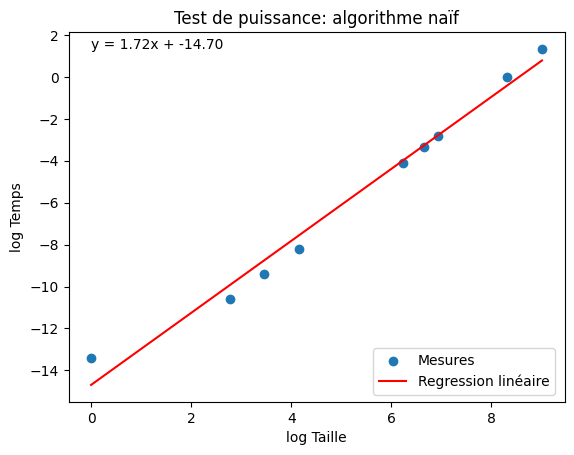

In [306]:
import math

def values_test_puissance(measures):
    return {
        # TODO: calculez les valeurs pour le test de puissance
        math.log(size): math.log(measure)
        for size, measure in measures.items()
        if size > 0 and measure > 0
        
    }

display_test_puissance(values_test_puissance(measures_bruteforce), "Test de puissance: algorithme naïf")


Analyse du graphe obtenu pour le test de puissance.
On observe une croissance polynomiale de degré 1.93. On est donc proche d'une complexité temporelle de O(n²).

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Complétez d'abord la fonction `values_test_rapport` permettant d'obtenir les valeurs à reporter sur le graphe. Puis utilisez la fonction `display_test_rapport` pour afficher le graphe.

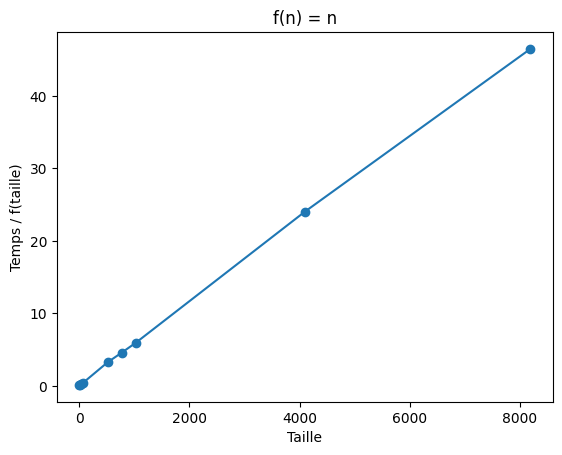

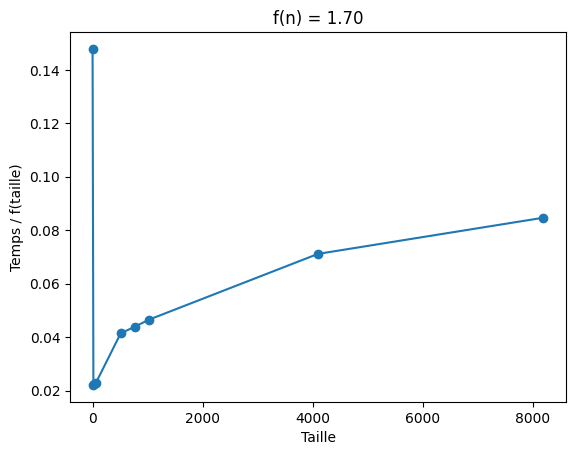

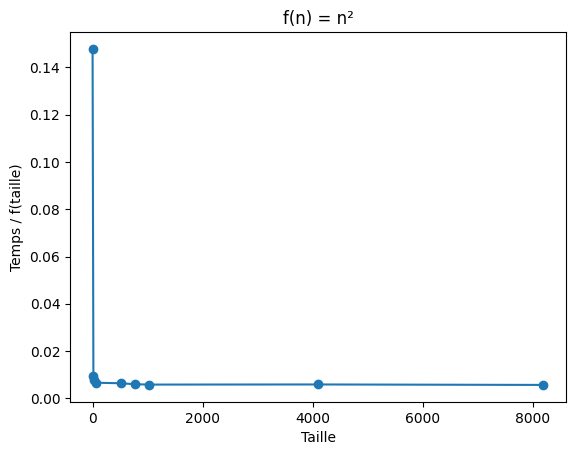

In [391]:
def values_test_rapport(measures,f):
    return {
        # TODO: calculez les valeurs pour le test du rapport
        size: measure / f(size)*100000
        for size, measure in measures.items()
        if f(size) != 0 and size>=1
    }

# TODO: definissez f judicieusement
def f(x):
    return  x
def f1(x):
    return  pow(x, 1.70)
def f2(x):
    return  pow(x, 2)

#test avec f(x) = x
display_test_rapport(values_test_rapport(measures_bruteforce, f),"f(n) = n")

#test avec f(x) = x^2
display_test_rapport(values_test_rapport(measures_bruteforce, f1),"f(n) = 1.70")
display_test_rapport(values_test_rapport(measures_bruteforce, f2),"f(n) = n²")

Anayse du graphe obtenu pour le test du rapport. Précisez le critère de choix de votre ou vos fonctions.

Étant donné que l'analyse asymptotique était O(n²), on teste avec f(x) = x². Avec cette fonction, la consommation bien qu'elle s'approche de 0, se stabilise entre 0.6 et 0.7(voir Graphe 2). C'est donc, selon notre échantillon, une bonne estimation

Pour confirmer cela, on a testé avec f(x) = x. Toutefois, comme on peut le voir avec le premier graphe,il n'y a pas de stabilité ni de convergence, donc on ne peut pas conclure que c'est une complexité O(n). 

Ainsi, c'est avec f(x) = x² qu'on retrouve une constante b environ égale à 0.65, ce qui nous donne la fonction cherché consommation = 0.65 · taille² ( y = b · f (x))

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Complétez d'abord la fonction `values_test_constantes` permettant d'obtenir les valeurs à reporter sur le graphe. Puis utilisez la fonction `display_test_constantes` pour afficher le graphe.

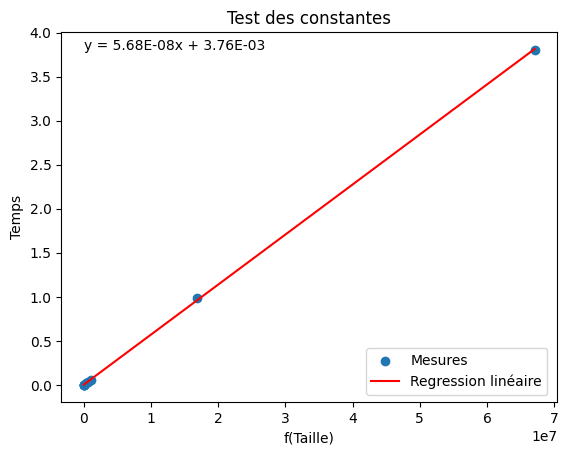

In [350]:
def values_test_constantes(measures, f):
    return {
        # TODO: calculez les valeurs pour le test du rapport f(x):y
        f(size): measure
        for size, measure in measures.items()
    }

# TODO: définissez f judicieusement
def f(x):
    return pow(x,2)

display_test_constantes(values_test_constantes(measures_bruteforce, f))

TODO: Indiquez les valeurs des constantes mises en évidence par le test.

On observe bien une droite avec c = 6,27 × 10⁻⁸ et b = 7,15 × 10⁻⁴


## Algorithme diviser pour régner (6 points)


### Implémentation (1.5 points)

TODO: Implantez un algorithme pour le problème de la ligne d'horizon utlisant le patron de conception "Diviser pour régner".

Il est conseillé de prévoir un paramètre pour le seuil de récursivité (e.g. `threshold`), en dessous duquel, vous utiliserez l'algorithme naïf écrit précédemment. Dans ce cas, le seuil devrait être 1.

In [399]:
# def skyline_divide_and_conquer(buildings, threshold):
#     skyline = []
#     # TODO: Implantez un algorithme diviser-pour-régner
#     if len(buildings) <= threshold:
#         skyline = skyline_bruteforce(buildings)
#         return skyline

#     split_arrays = np.array_split(buildings, 2) # Split into 2 parts

#     first_half_np = split_arrays[0]
#     second_half_np = split_arrays[1]

#     # while x jusqua len(buildinds) // Cette ligne est nécessaire??
     
#         #skiline_fisrt = skyline_divide_and_conquer(first_half_np)
#     skyline_first = skyline_divide_and_conquer(first_half_np, threshold)
#         #skiline_second = skyline_divide_and_conquer(second_half_np)
#     skyline_second = skyline_divide_and_conquer(second_half_np, threshold)
    
    
#     # Merge
#     i = j = 0
#     h1 = h2 = 0
#     merged = []

#     while i < len(skyline_first) and j < len(skyline_second):
#         if skyline_first[i][0] < skyline_second[j][0]:
#             x, h1 = skyline_first[i]
#             i += 1
#         elif skyline_second[j][0] < skyline_first[i][0]:
#             x, h2 = skyline_second[j]
#             j += 1
#         else:  # mêmes x
#             x = skyline_first[i][0]
#             h1 = skyline_first[i][1]
#             h2 = skyline_second[j][1]
#             i += 1
#             j += 1

#         max_h = max(h1, h2)
#         if not merged or merged[-1][1] != max_h:
#             merged.append((x, max_h))

#     # Ajouter les points restants
#     merged.extend(skyline_first[i:])
#     merged.extend(skyline_second[j:])

#     return merged

# verification_plot(example_buildings, skyline_divide_and_conquer(example_buildings,1))
def skyline_divide_and_conquer(buildings, threshold=1):
    """
    Compute the skyline using divide and conquer with a threshold for naive solution.
    
    Args:
        buildings: List of [left, right, height] tuples
        naive_threshold: Use naive solution when number of buildings <= this value
    
    Returns:
        List of [x, height] points representing the skyline
    """
    if not buildings:
        return []
    
    # Use naive solution for small inputs
    if len(buildings) <= threshold:
        return skyline_bruteforce(buildings)
    
    # Divide: split buildings into left and right halves
    mid = len(buildings) // 2
    left_skyline = skyline_divide_and_conquer(buildings[:mid], threshold)
    right_skyline = skyline_divide_and_conquer(buildings[mid:], threshold)
    
    # Conquer: merge the two skylines
    return merge_skylines(left_skyline, right_skyline)


def merge_skylines(left, right):
    """
    Merge two skylines using a two-pointer approach.
    """
    result = []
    i = j = 0
    h_left = h_right = 0  # Current heights from each skyline
    n, m = len(left), len(right)
    
    while i < n and j < m:
        x1, height1 = left[i]
        x2, height2 = right[j]
        
        if x1 < x2:
            h_left = height1
            current_height = max(h_left, h_right)
            add_skyline_point(result, x1, current_height)
            i += 1
        elif x2 < x1:
            h_right = height2
            current_height = max(h_left, h_right)
            add_skyline_point(result, x2, current_height)
            j += 1
        else:  # x1 == x2
            h_left = height1
            h_right = height2
            current_height = max(h_left, h_right)
            add_skyline_point(result, x1, current_height)
            i += 1
            j += 1
    
    # Add remaining points from left skyline
    while i < n:
        add_skyline_point(result, left[i][0], left[i][1])
        i += 1
    
    # Add remaining points from right skyline
    while j < m:
        add_skyline_point(result, right[j][0], right[j][1])
        j += 1
    
    return result


def add_skyline_point(skyline, x, height):
    """
    Add a point to the skyline only if it changes the height.
    Prevents duplicate points with the same height.
    """
    if not skyline:
        skyline.append([x, height])
    else:
        last_x, last_height = skyline[-1]
        if height != last_height:
            # If same x-coordinate, update the height instead of adding new point
            if x == last_x:
                skyline[-1][1] = max(skyline[-1][1], height)
            else:
                skyline.append([x, height])



TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

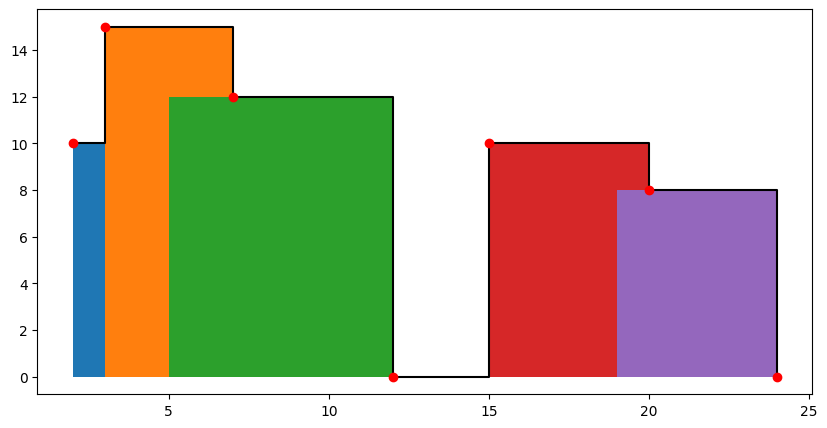

In [400]:
def skyline_divide_and_conquer_naive_threshold(buildings):
    # TODO diviser pour régner avec un seuil de récursivité de 1
    skyline_divide_and_conquer(buildings, 1)
    return []
verification_plot(example_buildings, skyline_divide_and_conquer(example_buildings,1))

### Analyse asymptotique (1 points)

TODO: Quelle est la complexité asymptotique théorique de cet algorithme?


Selon le Master Théorème, "T(n) = lT (n/b) + cnk" où l=2 appels récursifs, b=2 puisque nous divisons en 2 sous ensembles de même taille, k=1 puisque la partie du "merge" se fait en O(n)
nous avons alors pour T(n)=2T(n/2) + cn  un theta de nlog(n)

Que la liste de bâtiment soit parfaite ou non, l'algorithme devra s'accomplir au complet afin de mettres les points.

### Mesures (0.5 points)

In [401]:
measures_divide_naive_threshold = measure_procedure(skyline_divide_and_conquer_naive_threshold, dataset)

In [402]:
display_measures_table(measures_divide_naive_threshold)

Taille       Temps moyen (s)
1            1.71661376953125e-06
16           4.224777221679687e-05
32           8.149147033691407e-05
64           0.00018033981323242187
512          0.0017919540405273438
768          0.002714204788208008
1024         0.0036737918853759766
4096         0.01781315803527832
8192         0.035985374450683595


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Utilisez la fonction `display_test_puissance` pour afficher le graphe.

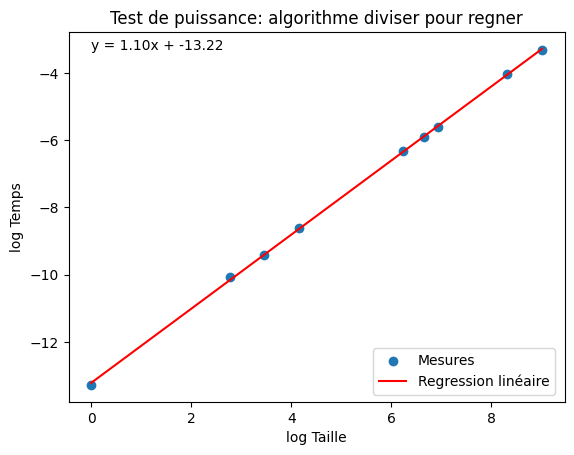

In [403]:
display_test_puissance(values_test_puissance(measures_divide_naive_threshold), "Test de puissance: algorithme diviser pour regner")

TODO: Analysez le graphe obtenu pour le test de puissance.
On obtient un coefficient un peu superieur à 1, indiquant donc une croissance pas tout à fait polynomiale, un

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_rapport` pour afficher le graphe.

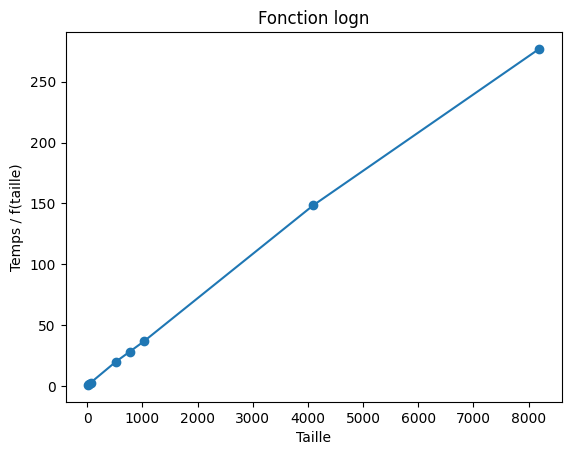

{16: 1.0561943054199219, 32: 1.6298294067382812, 64: 3.0056635538736978, 512: 19.910600450303818, 768: 28.317322973395, 1024: 36.737918853759766, 4096: 148.44298362731934, 8192: 276.8105726975661}


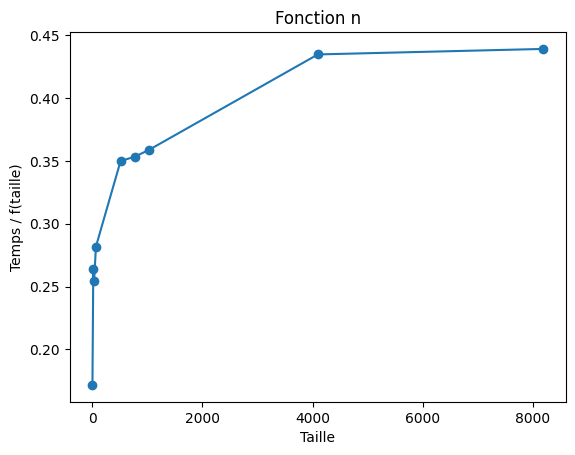

{1: 0.171661376953125, 16: 0.26404857635498047, 32: 0.25466084480285645, 64: 0.2817809581756592, 512: 0.3499910235404968, 768: 0.3534120817979177, 1024: 0.3587687388062477, 4096: 0.4348915535956621, 8192: 0.4392745904624462}


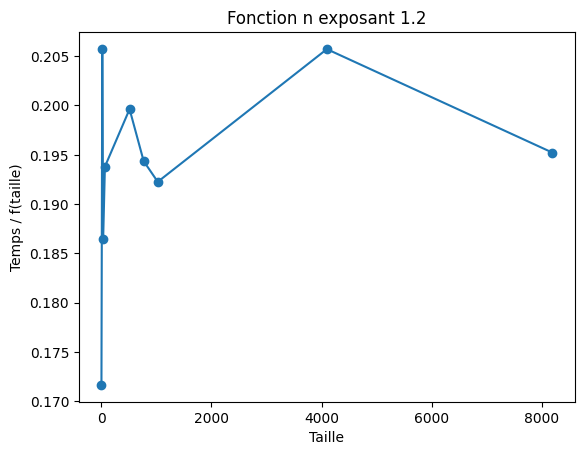

{1: 0.171661376953125, 16: 0.20573729800558171, 32: 0.18642265009664544, 64: 0.1938007457630526, 512: 0.19962853026732494, 768: 0.19435641624794736, 1024: 0.1922594067200754, 4096: 0.20571623988777507, 8192: 0.1952230023774937}


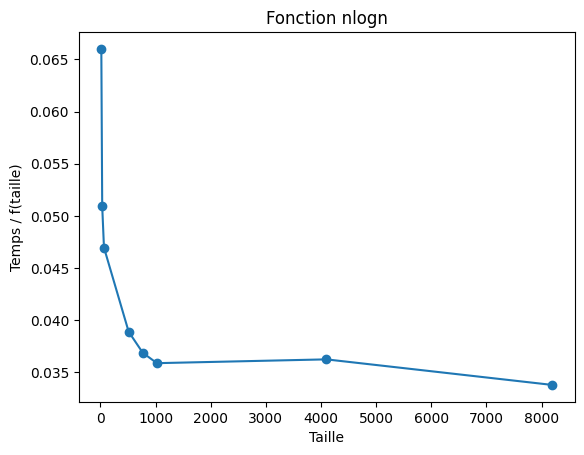

{16: 0.06601214408874512, 32: 0.05093216896057129, 64: 0.04696349302927653, 512: 0.038887891504499644, 768: 0.03687151428827474, 1024: 0.03587687388062477, 4096: 0.03624096279963851, 8192: 0.03379035311249586}


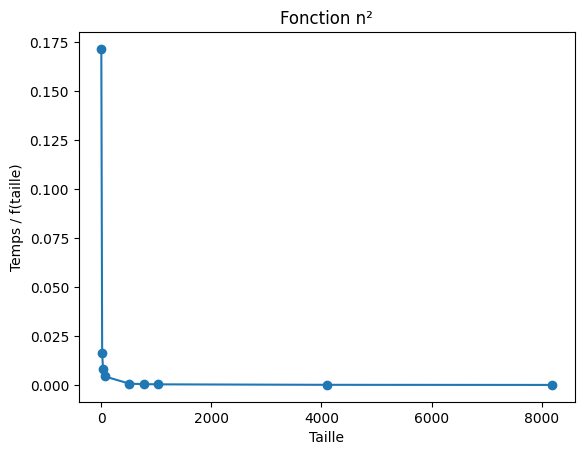

{1: 0.171661376953125, 16: 0.01650303602218628, 32: 0.007958151400089264, 64: 0.004402827471494675, 512: 0.0006835762178525329, 768: 0.00046017198150770535, 1024: 0.0003503600964904763, 4096: 0.00010617469570206595, 8192: 5.362238653106033e-05}


In [404]:
# TODO: définissez f judicieusement
def flog(x):
    return math.log(x,2) #log(n)
def fn(x): # n
    return x
def f1(x):
    return pow(x,1.09)
def fnlogn(x):
    return math.log(x,2)*x #nlog(n)
def fn2(x):
    return pow(x,2) #n²

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, flog),"Fonction logn")
print(values_test_rapport(measures_divide_naive_threshold, flog))

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fn),"Fonction n")
print(values_test_rapport(measures_divide_naive_threshold, fn))

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, f1),"Fonction n exposant 1.2")
print(values_test_rapport(measures_divide_naive_threshold, f1))

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fnlogn),"Fonction nlogn")
print(values_test_rapport(measures_divide_naive_threshold, fnlogn))

display_test_rapport(values_test_rapport(measures_divide_naive_threshold, fn2),"Fonction n²")
print(values_test_rapport(measures_divide_naive_threshold, fn2))

TODO: Analysez le graphe obtenu pour le test du rapport.

- Avec le test du rapport, avec f(n) = log(n), on sous-estime
- Avec le test du rapport, avec f(n) = n et n^(1.2), on semble converger
- Avec le test du rapport, avec f(n) = n² et nlnog(n) on surestime

Étant certainement au-dessus d'une complexité n et certainement en dessous de n², nlog(n) reste une réponse raisonnable.

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_constantes` pour afficher le graphe.

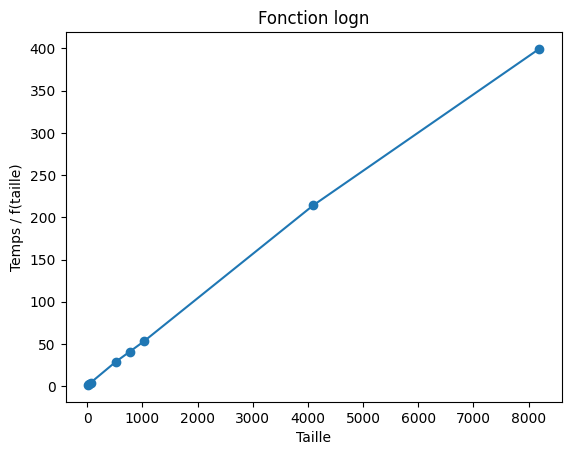

{16: 1.5237662866444843, 32: 2.3513468025963196, 64: 4.336255903754282, 512: 28.72492453077488, 768: 40.85326142496808, 1024: 53.00161334290036, 4096: 214.1579563338952, 8192: 399.3532404964126}


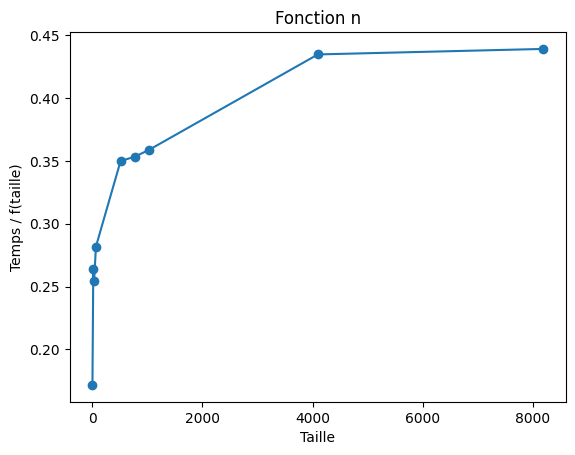

{1: 0.171661376953125, 16: 0.26404857635498047, 32: 0.25466084480285645, 64: 0.2817809581756592, 512: 0.3499910235404968, 768: 0.3534120817979177, 1024: 0.3587687388062477, 4096: 0.4348915535956621, 8192: 0.4392745904624462}


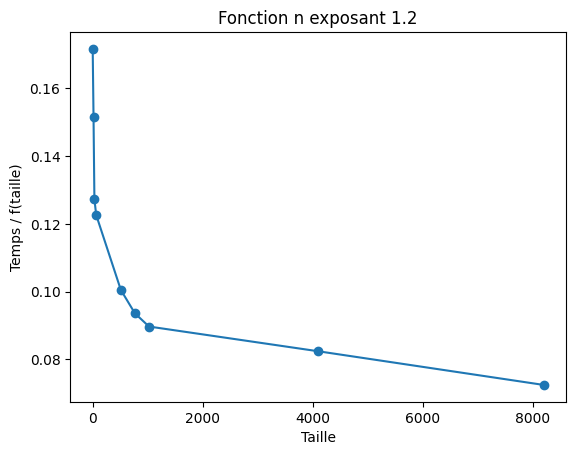

{1: 0.171661376953125, 16: 0.15165608264913755, 32: 0.12733042240142825, 64: 0.12265228593297087, 512: 0.10050852825117436, 768: 0.09358562568876189, 1024: 0.08969218470156196, 4096: 0.08239654155254876, 8192: 0.07245328713959018}


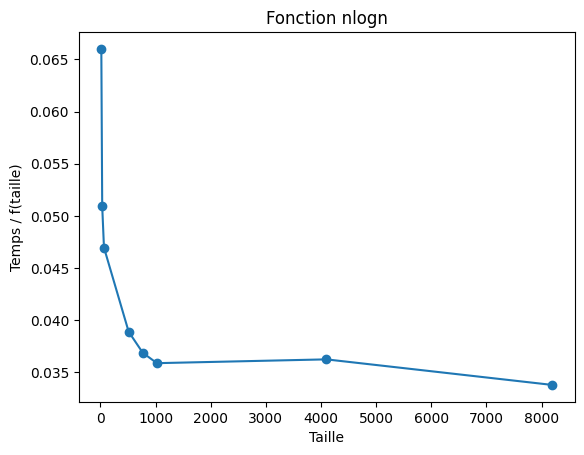

{16: 0.06601214408874512, 32: 0.05093216896057129, 64: 0.04696349302927653, 512: 0.038887891504499644, 768: 0.03687151428827474, 1024: 0.03587687388062477, 4096: 0.03624096279963851, 8192: 0.03379035311249586}


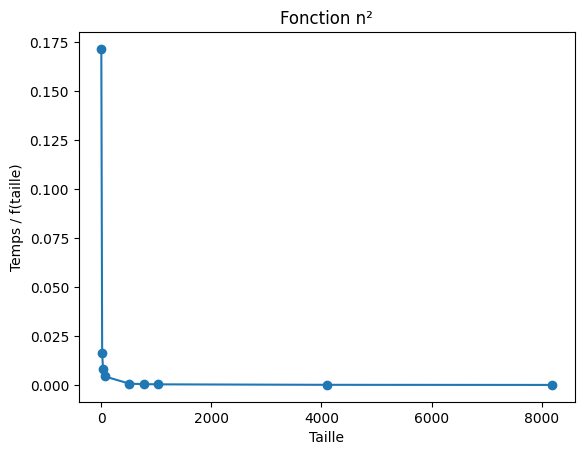

{1: 0.171661376953125, 16: 0.01650303602218628, 32: 0.007958151400089264, 64: 0.004402827471494675, 512: 0.0006835762178525329, 768: 0.00046017198150770535, 1024: 0.0003503600964904763, 4096: 0.00010617469570206595, 8192: 5.362238653106033e-05}


In [ ]:
# TODO: définissez f judicieusement
def f(x):
    return x
def f2(x):
    return x**2
def fnlogn(x):
    return x*math.log(x,2)

display_test_constantes(values_test_constantes(measures_divide_naive_threshold, f),"n")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, fnlogn),"n²")
display_test_constantes(values_test_constantes(measures_divide_naive_threshold, f2),"nlog(n)")



TODO: Indiquez les valeurs des constantes mises en évidence par le test.

## Algorithme diviser pour régner (seuil choisi) (6 points)

### Sélection du seuil (1.5 points)

Effectuez les mesures avec plusieurs seuils de récursivité pour déterminer le seuil le plus judicieux.

In [429]:
# example_sample = dataset[10000][0]
# measures_threshold = {


#     i:
#     measure_mean_time(
#         lambda sample: skyline_divide_and_conquer(sample, i),
#         [example_sample]) # TODO: sélectionnez un exemplaire
#         for i in [ 1,2,3,4, 5,10,15,20,50] # TODO: testez une liste judicieuse de seuils
        

# }
# print(measures_threshold)
# thresholds = [1, 2, 4, 8, 12, 16, 32, 128, 256, 512, 1024]
thresholds = [2**x for x in range(0,10)]
[print(t) for t in thresholds]
measures_threshold = {
    i:
    measure_mean_time(
        lambda sample: skyline_divide_and_conquer(sample, i),[generate_sample(64)]) # TODO: sélectionnez un exemplaire
        for i in thresholds # TODO: testez une liste judicieuse de seuils
}

1
2
4
8
16
32
64
128
256
512


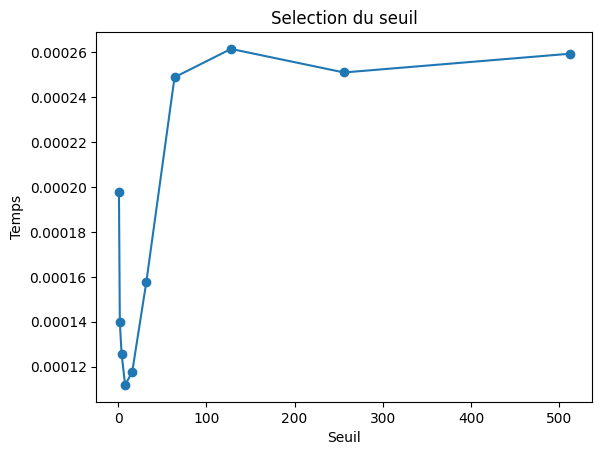

In [430]:

display_mesures_seuil(measures_threshold)


TODO: Quel est le seuil de récursivité de le plus judicieux ? Sur quel critère l'avez vous sélectionné ?

L'analyse sur de petits seuils (1–50) montre que le temps d’exécution est petit pour un seuil très faible, autour de 4 (≈0.17 s). Lorsque le seuil augmente, les performances diminuent, (0.9 s pour un seuil de 50). Le seuil optimal est 4.

Nous nous somme basé sur le critère de complexité asymptotique du code. Il fallait qu'on trouve l'équilibre entre le coût quadratique du skyline_bruteforce (≈ O(n²)) et le coût de merge (≈ O(n)). On a donc choisit de mettre le seuil très petit, car si c'est trop grand, la complexité quadratique domine grandement. 

TODO: Utilisez votre fonction générique pour implanter un algorithme avec le seuil choisi.

TODO: Utilisez la fonction `verification_plot` sur l'exemplaire de présentation du problème `example_buildings` pour vérifier l'exactitude de votre algorithme et laissez la figure dans votre rapport.

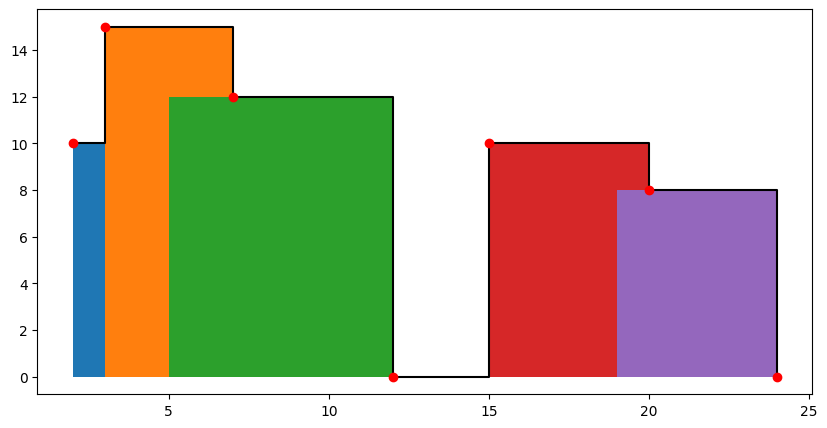

In [417]:
def skyline_divide_and_conquer_best_threshold(buildings):
    # TODO diviser pour régner avec un seuil de récursivité de n
    return skyline_divide_and_conquer(buildings, 8)

verification_plot(example_buildings,skyline_divide_and_conquer_best_threshold(example_buildings))

### Analyse asymptotique (1 points)

TODO: Quelle est la complexité asymptotique théorique de cet algorithme?

### Mesures (0.5 points)

In [409]:
measures_divide_best_threshold = measure_procedure(skyline_divide_and_conquer_best_threshold,dataset)

In [410]:
display_measures_table(measures_divide_best_threshold)

Taille       Temps moyen (s)
1            1.52587890625e-06
16           2.1505355834960938e-05
32           5.269050598144531e-05
64           0.00011625289916992188
512          0.0013820648193359375
768          0.002009677886962891
1024         0.0027356624603271486
4096         0.015045976638793946
8192         0.027648019790649413


### Analyse hybride

#### Test de puissance (1 point)

Effectuez le test de puissance de votre algorithme.

Utilisez la fonction `display_test_puissance` pour afficher le graphe.

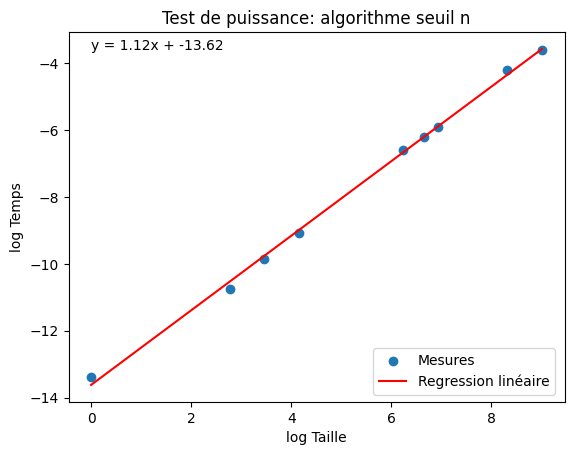

In [411]:
display_test_puissance(values_test_puissance(measures_divide_best_threshold), "Test de puissance: algorithme seuil n")

Analysez le graphe obtenu pour le test de puissance.

#### Test du rapport (1 point)

Effectuez le test du rapport avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_rapport` pour afficher le graphe.

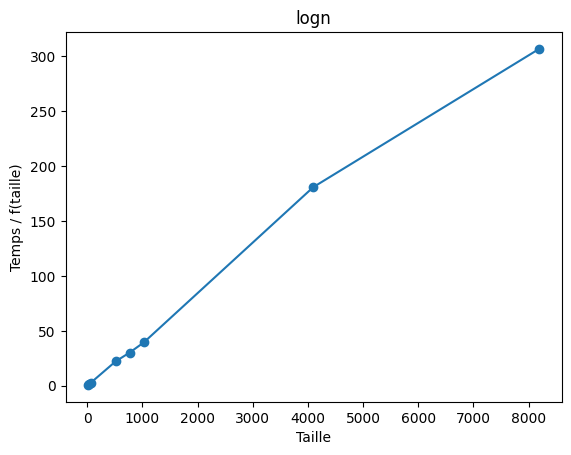

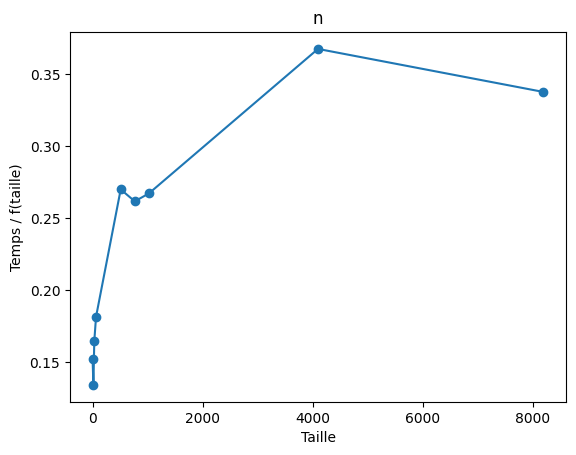

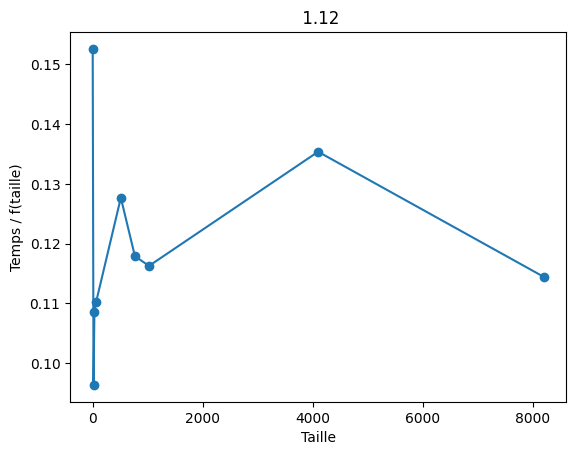

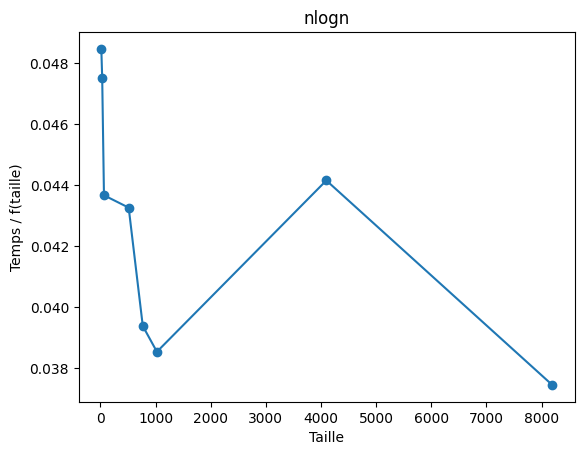

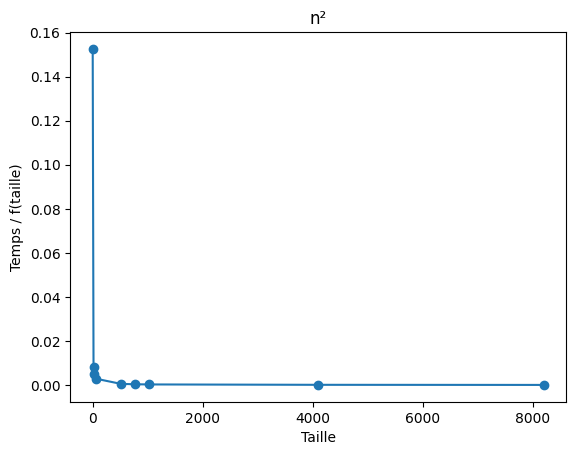

In [422]:
# TODO: définissez f judicieusement

def flog(x):
    return math.log(x) #log(n)
def fn(x): # n
    return x
def f1(x):
    return pow(x,1.12)
def fnlogn(x):
    return math.log(x)*x #nlog(n)
def fn2(x):
    return pow(x,2) #n²


display_test_rapport(values_test_rapport(measures_divide_best_threshold, flog),"logn")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fn),"n")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, f1)," 1.12")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fnlogn),"nlogn")
display_test_rapport(values_test_rapport(measures_divide_best_threshold, fn2),"n²")


TODO: Analysez le graphe obtenu pour le test du rapport.

### Test des constantes (1 point)

Effectuez le test des constantes avec une ou plusieurs fonctions f pertinentes.

Utilisez la fonction `display_test_constantes` pour afficher le graphe.

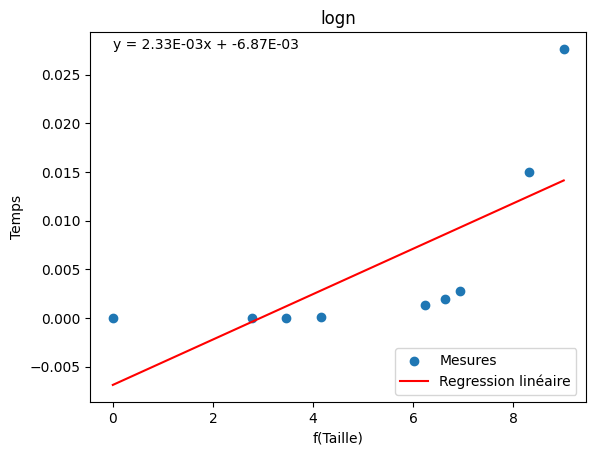

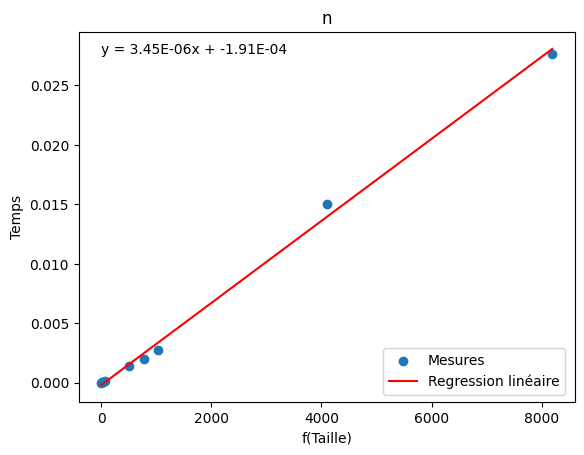

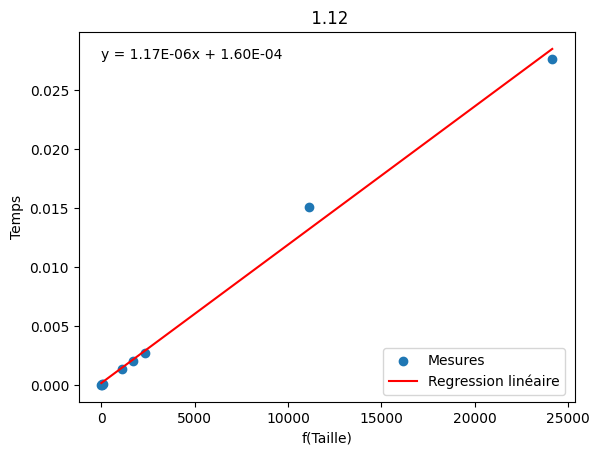

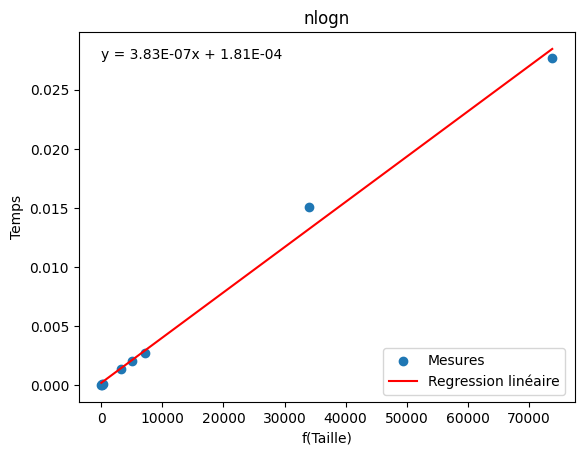

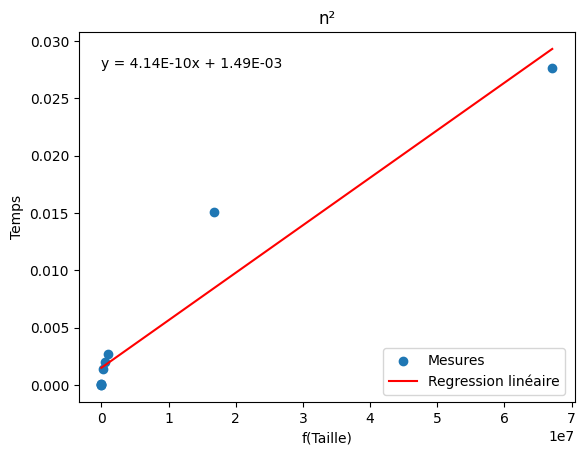

In [431]:
# TODO: définissez f judicieusement

display_test_constantes(values_test_constantes(measures_divide_best_threshold, flog),"logn")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fn),"n")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, f1)," 1.12")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fnlogn),"nlogn")
display_test_constantes(values_test_constantes(measures_divide_best_threshold, fn2),"n²")

TODO: Indiquez les valeurs des constantes mises en évidence par le test.

# Conclusion (2 points)


TODO: Commentez l'impact du seuil de récursivité. Que représente t'il pour l'algorithme diviser pour régner et l'algorithme naïf ?

TODO: En vous basant sur vos résultats, résumez vos découvertes et analyses, et indiquez dans quelles circonstances vous utiliserez chacun de ces 3 algorithmes en démontrant leurs points forts et point faibles.

 ## Autres critères


Présentation générale / -
1 pt

- Concision
- Qualité du français

Pénalité retard
- -1 pt / journée de retard, arrondi vers le haut. Les TPs ne sont plus acceptés après 3 jours.